# HW3: Unsupervised Learning & Dimensionality Reduction

**Course:** Fundamentals of Machine Learning (MSAI)  
**Topics:** K-Means, Gaussian Mixture Models (EM), PCA, LDA Projection  

---

## Overview

In this assignment you will:

1. **Implement K-Means** clustering and analyze its behavior on synthetic data  
2. **Implement a Gaussian Mixture Model** (GMM) via the EM algorithm, focusing on computing responsibilities and weighted MLE parameter updates  
3. **Implement PCA** (unsupervised dimensionality reduction) and analyze variance capture  
4. **Implement LDA Projection** (supervised dimensionality reduction) and compare it with PCA  
5. **Apply your tools** to the UCI Heart Disease dataset in an integrative analysis pipeline  

## Files

| File | Description |
|------|-------------|
| `clustering.py` | **Your implementations** of `KMeans` and `GMM` classes |
| `dimensionality_reduction.py` | **Your implementations** of `PCA` and `LDAProjection` classes |
| `utils.py` | Provided helper functions (plotting, data generation). **Do not modify.** |
| `HW3_Analysis.ipynb` | **This notebook.** Testing, visualization, and conceptual questions. |

## Deliverables

1. Completed `clustering.py` and `dimensionality_reduction.py`  
2. This notebook with all cells executed and all questions answered  
3. PDF export of this notebook  

## Approved Libraries

- **Implementation files** (`clustering.py`, `dimensionality_reduction.py`): `numpy`, `scipy`
- **This notebook**: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`, `sklearn` (for comparison and pipeline tasks only)

---

In [1]:
# Standard imports — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    generate_synthetic_clusters, log_sum_exp,
    plot_clusters, plot_gmm_contours, plot_responsibilities,
    plot_scree, plot_projection_2d, plot_comparison
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

---

## Part 1: K-Means Clustering

Implement the `KMeans` class in `clustering.py`, then return here to test it.

**Methods to implement:** `_assign_clusters`, `_update_centroids`, `fit`, `predict`

### 1.1 Generate Synthetic Data

Data shape: (900, 2)


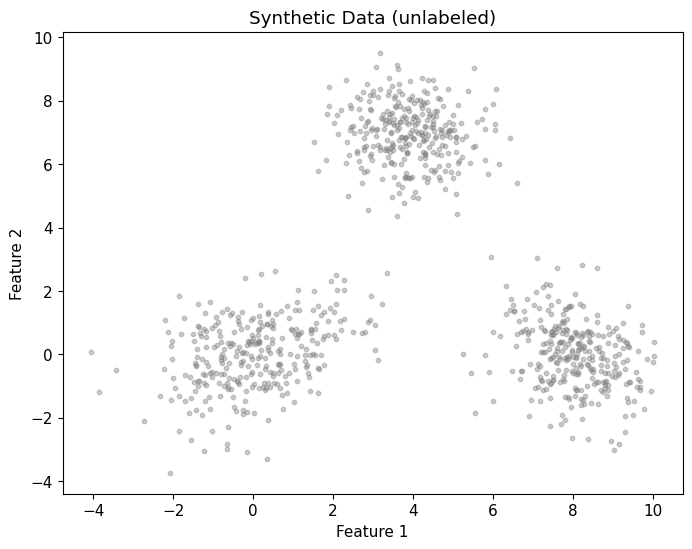

In [2]:
# Three well-separated 2D Gaussian clusters
means = [[0, 0], [8, 0], [4, 7]]
covariances = [
    [[1.5, 0.5], [0.5, 1.5]],
    [[1.0, -0.3], [-0.3, 1.0]],
    [[0.8, 0], [0, 0.8]]
]

X_synth, y_synth = generate_synthetic_clusters(
    means, covariances, n_samples_per_cluster=300, random_state=42
)

print(f"Data shape: {X_synth.shape}")
plt.figure(figsize=(8, 6))
plt.scatter(X_synth[:, 0], X_synth[:, 1], s=10, alpha=0.4, c='gray')
plt.title('Synthetic Data (unlabeled)')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.show()

### 1.2 Fit K-Means

Converged in 4 iterations
Inertia: 1974.12
Centroids:
[[ 4.35430698e-02  1.11243519e-03]
 [ 3.89818090e+00  6.95893920e+00]
 [ 8.02145214e+00 -2.82851210e-02]]


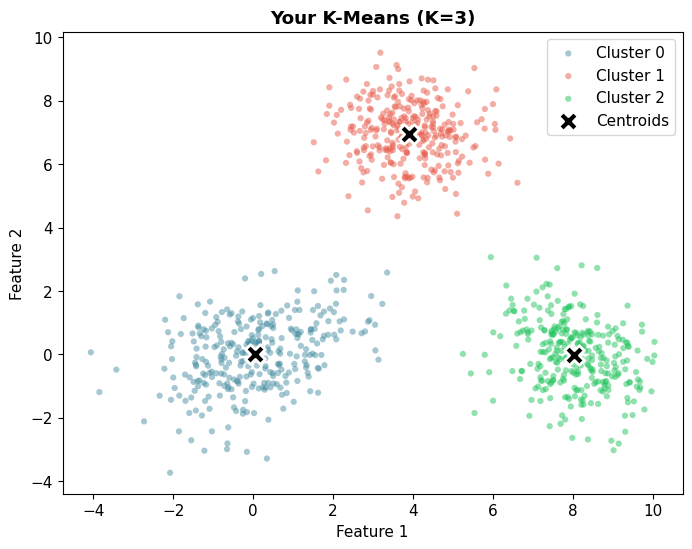

In [3]:
from clustering import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(X_synth)

print(f"Converged in {km.n_iter_} iterations")
print(f"Inertia: {km.inertia_:.2f}")
print(f"Centroids:\n{km.get_centroids()}")

plot_clusters(X_synth, km.labels_, km.get_centroids(),
              title='Your K-Means (K=3)')
plt.show()

### 1.3 Compare with sklearn

C:\Users\singh\anaconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


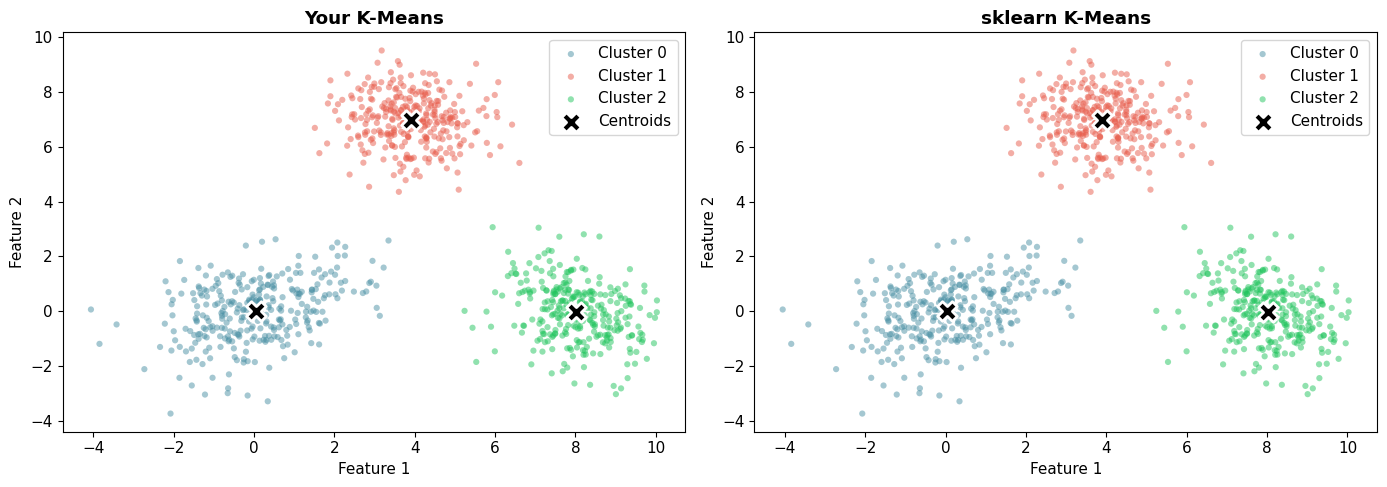

Your inertia:    1974.12
sklearn inertia: 1974.12


In [4]:
from sklearn.cluster import KMeans as SklearnKMeans

km_sk = SklearnKMeans(n_clusters=3, random_state=42, n_init=1)
km_sk.fit(X_synth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_clusters(X_synth, km.labels_, km.get_centroids(),
              title='Your K-Means', ax=axes[0])
plot_clusters(X_synth, km_sk.labels_, km_sk.cluster_centers_,
              title='sklearn K-Means', ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Your inertia:    {km.inertia_:.2f}")
print(f"sklearn inertia: {km_sk.inertia_:.2f}")

### 1.4 Choosing K: Elbow Method

Run K-Means for K = 1, 2, ..., 8 and plot inertia vs K.

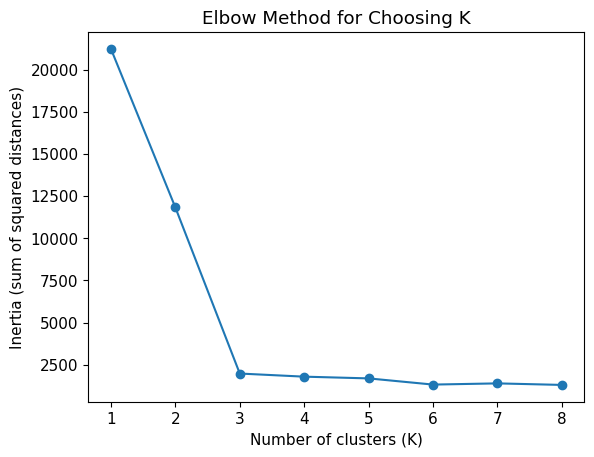

K values: [1, 2, 3, 4, 5, 6, 7, 8]
Inertias: [np.float64(21248.13196799546), np.float64(11835.15795125163), np.float64(1974.1166964801535), np.float64(1789.0944758192566), np.float64(1685.9229243007708), np.float64(1318.665970320798), np.float64(1389.7942315299686), np.float64(1298.4060512610158)]


In [5]:
# TODO: Run your KMeans for K=1..8, collect inertia values, and plot
# the elbow curve. Identify where the "elbow" is.
import numpy as np
import matplotlib.pyplot as plt
from clustering import KMeans

Ks = range(1, 9)
inertias = []

for K in Ks:
    km = KMeans(n_clusters=K, max_iter=300, tol=1e-4, random_state=42)
    km.fit(X_synth) 
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(list(Ks), inertias, marker='o')
plt.xticks(list(Ks))
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Method for Choosing K")
plt.show()

print("K values:", list(Ks))
print("Inertias:", inertias)

### 1.5 Conceptual Questions — K-Means

Answer the following in the markdown cells below.

**Q1.1:** Is K-Means guaranteed to find the globally optimal solution? Why or why not? What aspect of the algorithm introduces this behavior?

*Your answer:* No, K-Means is not guaranteed to find the global optimum. The final result depends on the initial placement of the centroids. Since the algorithm updates clusters step by step, it can get stuck in a local minimum instead of finding the best possible solution. Different random initializations can therefore produce different results.

**Q1.2:** K-Means uses hard assignments — each point belongs to exactly one cluster. What type of cluster shapes can K-Means discover effectively, and what shapes would it struggle with? Give an example of each.

*Your answer:* K-Means works best for spherical clusters of similar size because it uses Euclidean distance and assigns points to the nearest centroid. It struggles with elongated, elliptical, or non-convex shapes because distance to a centroid creates straight boundaries and round regions. For example, it performs well on well-separated Gaussian blobs but would struggle with two moons shaped data.

**Q1.3:** Looking at the elbow plot you generated, what value of K would you choose and why? Is the elbow always unambiguous?

*Your answer:* Look at the graph i think k will be 3 because the inertia decreases sharply up to K = 3 and then begins to level off. After this point, increasing K results in only small reductions in inertia, indicating diminishing returns. Therefore, K = 3 represents a good balance between model complexity and fit quality. Elbow is not always unambiguous. In some datasets, the curve decreases smoothly without a clear bend, making the choice of K subjective. In such cases, additional methods may be needed to select K.

---

## Part 2: Gaussian Mixture Models (EM Algorithm)

Implement the `GMM` class in `clustering.py`, then return here to test it.

**Methods to implement:** `compute_responsibilities`, `_m_step`, `fit`

Recall from the lectures:
- The **E-step** computes **responsibilities** — the posterior probability $\gamma(z_{nk})$ that sample $n$ belongs to component $k$
- The **M-step** uses these responsibilities as weights to compute **weighted MLE** updates for the means, covariances, and mixing weights

### 2.1 Fit GMM

In [6]:
from clustering import GMM

gmm = GMM(n_components=3, max_iter=100, random_state=42)
gmm.fit(X_synth)

params = gmm.get_params()
print(f"Converged in {gmm.n_iter_} iterations")
print(f"\nLearned means:\n{params['means']}")
print(f"\nMixing weights: {params['weights']}")

Converged in 2 iterations

Learned means:
[[ 4.39219331e-02  1.40722626e-03]
 [ 3.89826815e+00  6.95898071e+00]
 [ 8.02158562e+00 -2.83661987e-02]]

Mixing weights: [0.33336475 0.33332102 0.33331423]


### 2.2 Visualize Hard vs Soft Assignments

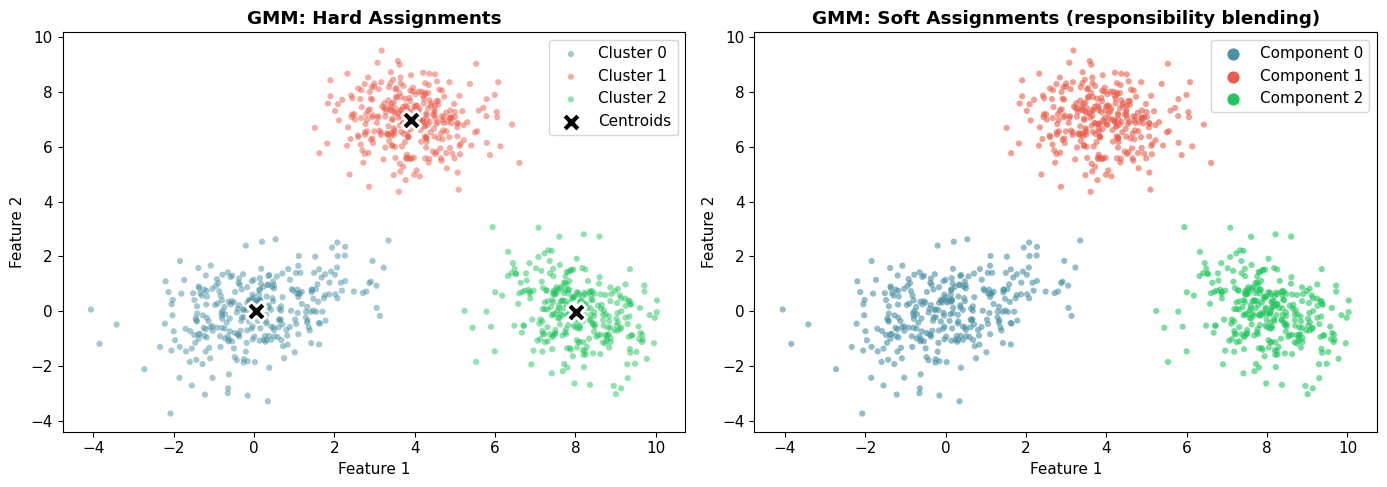

In [7]:
# Hard assignments (argmax of responsibilities)
gmm_labels = gmm.predict(X_synth)

# Soft assignments (full responsibility matrix)
responsibilities = gmm.predict_proba(X_synth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_clusters(X_synth, gmm_labels, params['means'],
              title='GMM: Hard Assignments', ax=axes[0])
plot_responsibilities(X_synth, responsibilities,
                      title='GMM: Soft Assignments (responsibility blending)',
                      ax=axes[1])
plt.tight_layout()
plt.show()

### 2.3 GMM Contours

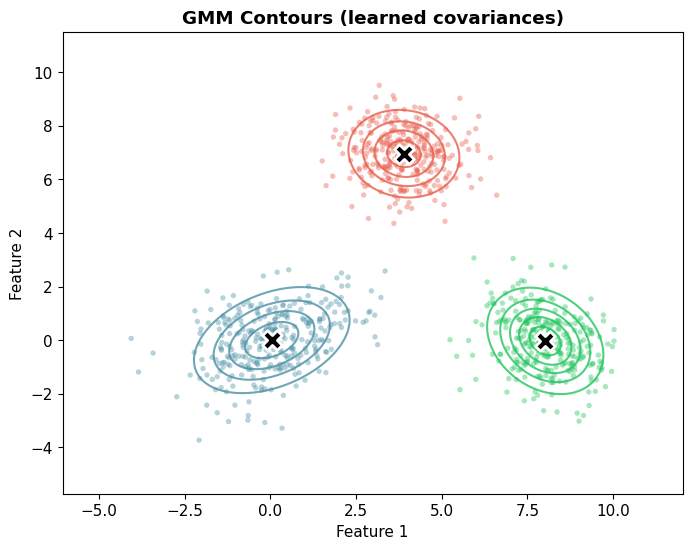

In [8]:
plot_gmm_contours(X_synth, params['means'], params['covariances'],
                  params['weights'], labels=gmm_labels,
                  title='GMM Contours (learned covariances)')
plt.show()

### 2.4 Convergence: Log-Likelihood Trace

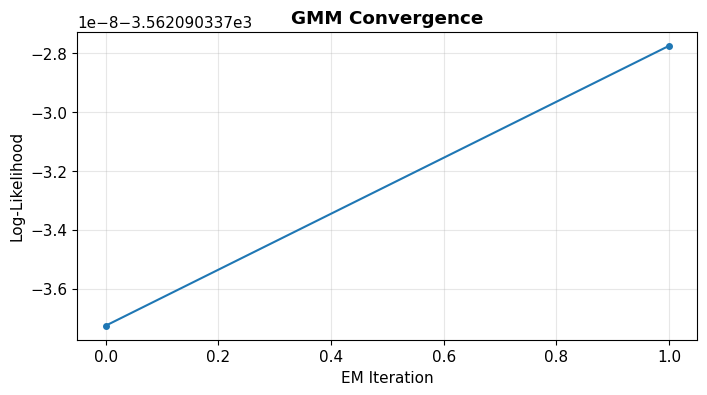

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(gmm.log_likelihoods_, marker='o', markersize=4)
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.title('GMM Convergence', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

### 2.5 Compare with sklearn

C:\Users\singh\anaconda3\envs\ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


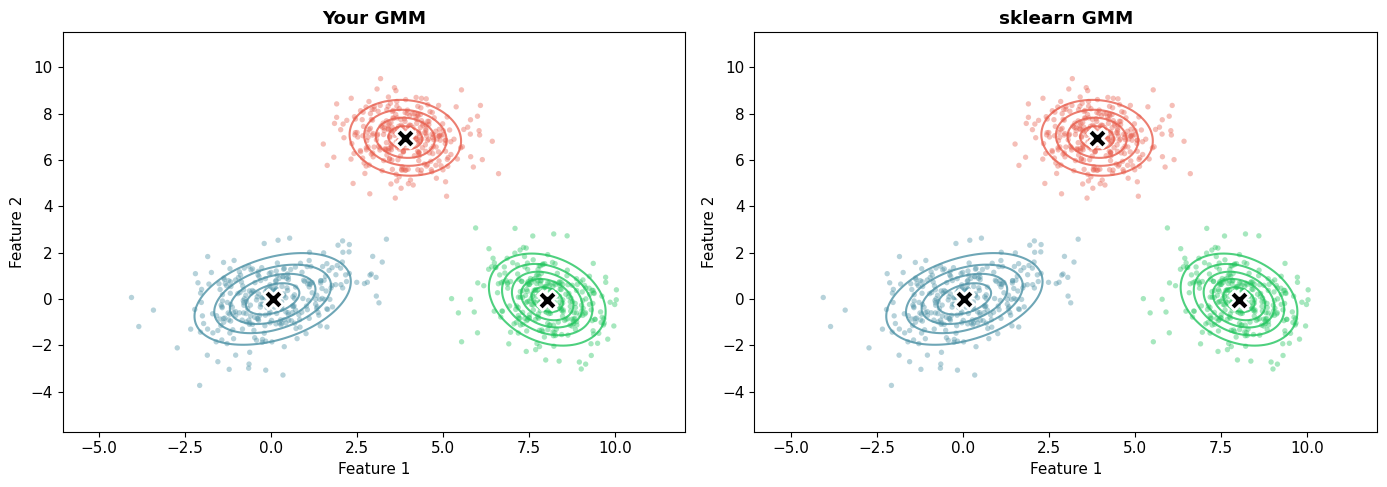

In [10]:
from sklearn.mixture import GaussianMixture as SklearnGMM

gmm_sk = SklearnGMM(n_components=3, random_state=42, n_init=1)
gmm_sk.fit(X_synth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_gmm_contours(X_synth, params['means'], params['covariances'],
                  params['weights'], labels=gmm_labels,
                  title='Your GMM', ax=axes[0])
plot_gmm_contours(X_synth, gmm_sk.means_, gmm_sk.covariances_,
                  gmm_sk.weights_, labels=gmm_sk.predict(X_synth),
                  title='sklearn GMM', ax=axes[1])
plt.tight_layout()
plt.show()

### 2.6 Conceptual Questions — GMM / EM

Answer the following in the markdown cells below.

**Q2.1:** In the E-step, you computed responsibilities $\gamma(z_{nk})$. In plain language, what does $\gamma(z_{nk}) = 0.7$ for a particular sample $n$ and component $k$ mean? How does this differ from K-Means?

*Your answer:* If $\gamma(z_{nk}) = 0.7$, it means that the model estimates there is a 70% probability that sample $n$ belongs to component $k$. The point mostly belongs to that cluster, but it may still partially belong to other clusters as well. K means use hard assignments make sure that each point belongs to exactly one cluster, GMM uses soft assignments where points can belong to multiple clusters with different probabilities.

**Q2.2:** The M-step formulas are *weighted* versions of the MLE updates you implemented in a previous homework. Specifically, the mean update is:

$$\mu_k = \frac{\sum_n \gamma(z_{nk})\, x_n}{\sum_n \gamma(z_{nk})}$$

Explain how this reduces to the standard MLE mean if every data point had responsibility 1 for one component and 0 for all others (i.e., hard assignments). What does this tell you about the relationship between K-Means and EM?

*Your answer:*


**Q2.3:** Look at your soft assignment plot (Section 2.2). Where do you see points with mixed responsibilities (blended colors)? Why do these regions have high uncertainty?

*Your answer:* Look at the plot, the soft assignment visualization looks very similar to the hard assignment because the clusters are well separated. Most points have responsibilities close to 1 for one component and close to 0 for the others. Only a small number of points near the cluster boundaries show slight blending. These boundary regions have higher uncertainty because the likelihood under multiple components is similar, leading to mixed responsibilities.

**Q2.4:** Your GMM log-likelihood trace should be monotonically non-decreasing. Why is this property guaranteed by the EM algorithm? (One or two sentences is sufficient.)

*Your answer:* The EM algorithm guarantees that the log-likelihood will not decrease because each E-step computes the optimal responsibilities given the current parameters, and each M-step maximizes the expected complete data log-likelihood with respect to the parameters. As a result, every iteration either increases or maintains the log-likelihood value.

---

## Part 3: Principal Component Analysis (PCA)

Implement the `PCA` class in `dimensionality_reduction.py`, then return here.

**Methods to implement:** `fit`, `transform`

### 3.1 PCA on the Iris Dataset

In [11]:
from sklearn.datasets import load_iris
from dimensionality_reduction import PCA

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
class_names = iris.target_names.tolist()

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Features: {iris.feature_names}")
print(f"Classes: {class_names}")

Iris dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']


Explained variance ratio per component:
  PC1: 0.9246 (92.5%)
  PC2: 0.0531 (5.3%)
  PC3: 0.0171 (1.7%)
  PC4: 0.0052 (0.5%)


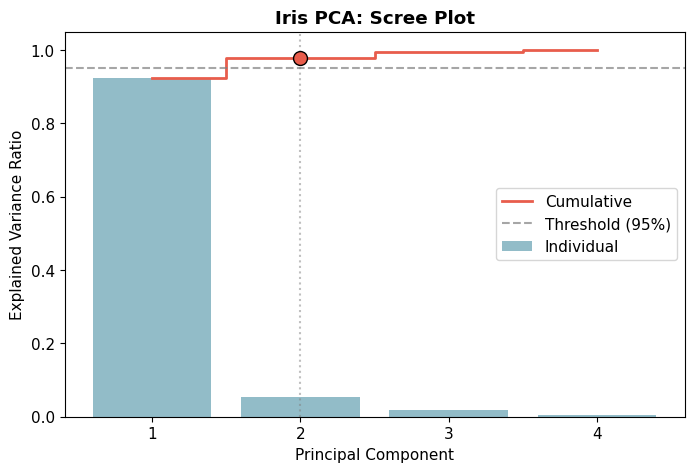

In [12]:
# Fit PCA keeping all 4 components first (for scree plot)
pca_full = PCA(n_components=4).fit(X_iris)

print("Explained variance ratio per component:")
for i, r in enumerate(pca_full.get_explained_variance_ratio()):
    print(f"  PC{i+1}: {r:.4f} ({r*100:.1f}%)")

plot_scree(pca_full.get_explained_variance_ratio(), threshold=0.95,
           title='Iris PCA: Scree Plot')
plt.show()

### 3.2 Project to 2D and Visualize

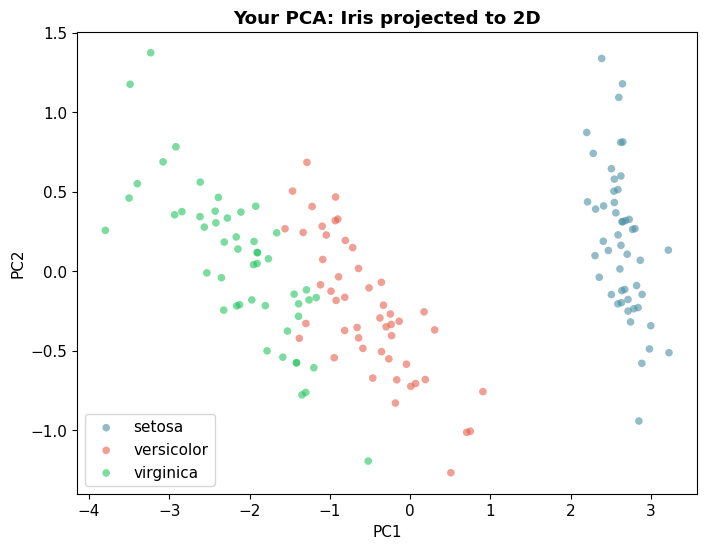

In [13]:
pca_2d = PCA(n_components=2).fit(X_iris)
X_pca = pca_2d.transform(X_iris)

plot_projection_2d(X_pca, y_iris, class_names,
                   xlabel='PC1', ylabel='PC2',
                   title='Your PCA: Iris projected to 2D')
plt.show()

### 3.3 Compare with sklearn

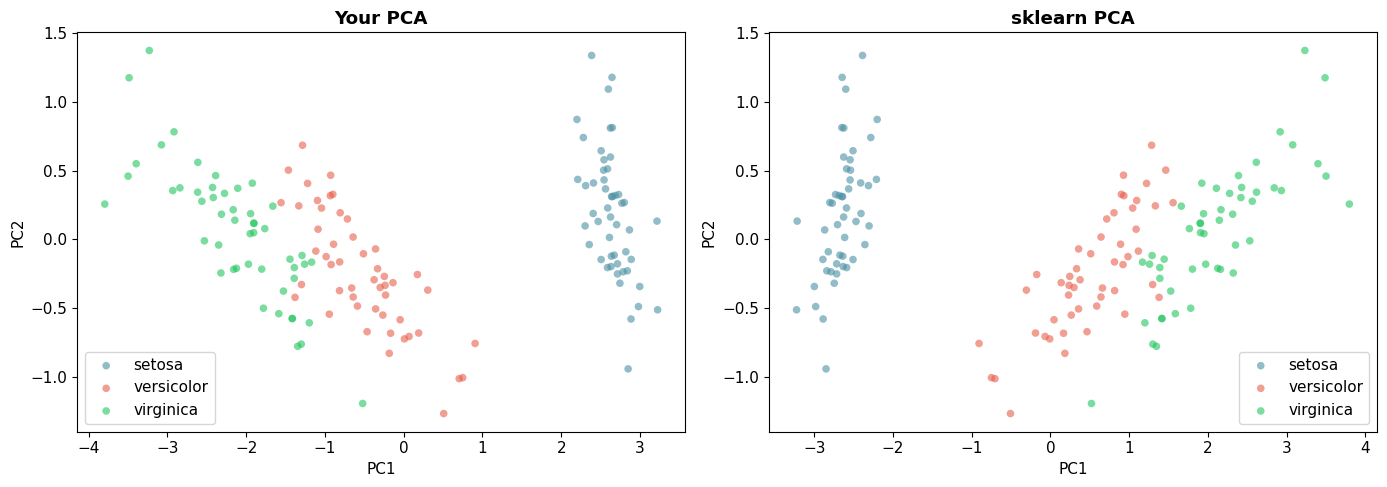

Explained variance ratio comparison:
  Yours:   [0.92461872 0.05306648]
  sklearn: [0.92461872 0.05306648]


In [14]:
from sklearn.decomposition import PCA as SklearnPCA

pca_sk = SklearnPCA(n_components=2).fit(X_iris)
X_pca_sk = pca_sk.transform(X_iris)

plot_comparison(X_pca, X_pca_sk, y_iris, class_names, method_name='PCA',
               xlabel='PC1', ylabel='PC2')
plt.show()

# Quantitative comparison
print("Explained variance ratio comparison:")
print(f"  Yours:   {pca_2d.get_explained_variance_ratio()}")
print(f"  sklearn: {pca_sk.explained_variance_ratio_}")

### 3.4 Variance Threshold Selection

In [15]:
# Test the automatic threshold-based selection
pca_auto = PCA(variance_threshold=0.95).fit(X_iris)

print(f"Components selected to capture >= 95% variance: {pca_auto.n_components_}")
print(f"Cumulative variance captured: {pca_auto.get_explained_variance_ratio().sum():.4f}")

Components selected to capture >= 95% variance: 2
Cumulative variance captured: 0.9777


### 3.5 Conceptual Questions — PCA

**Q3.1:** Why is it important to center the data (subtract the mean) before performing PCA? What would happen to the principal components if you skipped this step?

*Your answer:* Centering ensures that PCA analyzes variance around the true mean of the dataset. If we skip centering, the covariance matrix includes effects of the mean, and the first principal component may simply point toward the mean direction rather than capturing meaningful variance structure. This would distort the principal components.


**Q3.2:** PCA finds directions of maximum **variance**. Should you standardize (zero mean *and* unit variance) the features before PCA, or only center them? When would standardization be important, and when might it be unnecessary or harmful?

*Your answer:* The data must always be centered before PCA. but standardization depends on the situation. Standardization is important when features are measured on different scales, because PCA is variance based and larger scale features would dominate the principal components. However, if all features are already on comparable scales and the magnitude differences are meaningful, standardization may be unnecessary or even harmful, as it could remove important information about natural variability.

**Q3.3:** Looking at your scree plot, the first principal component captures the most variance. Explain in terms of the eigenvalue formulation $\Sigma w = \lambda w$ why the first component captures more variance than subsequent components.

*Your answer:* In $\Sigma w = \lambda w$, $\Sigma$ is the covariance matrix. Each eigenvector $w$ represents a direction in the data, and its eigenvalue $\lambda$ tells us how much variance exists along that direction. The first principal component corresponds to the largest eigenvalue, which means it captures the most variance in the data. The next components have smaller eigenvalues, so they explain less variance. That’s why the first component always captures the most spread. 

---

## Part 4: LDA Projection (Supervised Dimensionality Reduction)

Implement the `LDAProjection` class in `dimensionality_reduction.py`, then return here.

**Methods to implement:** `fit`, `transform`

Recall from the lectures:
- LDA finds directions that **maximize between-class separation** relative to **within-class scatter**
- It uses the Fisher criterion involving scatter matrices $S_W$ (within-class) and $S_B$ (between-class)
- Unlike PCA, LDA uses class labels — it is a **supervised** dimensionality reduction technique

### 4.1 LDA on the Iris Dataset

LDA components retained: 2
Explained variance ratio: [0.9912126 0.0087874]


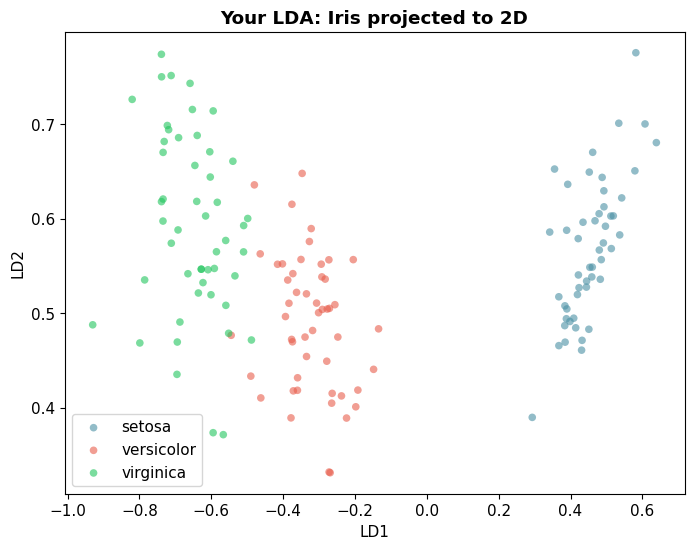

In [16]:
from dimensionality_reduction import LDAProjection

lda = LDAProjection(n_components=2).fit(X_iris, y_iris)
X_lda = lda.transform(X_iris)

print(f"LDA components retained: {lda.n_components_}")
print(f"Explained variance ratio: {lda.explained_variance_ratio_}")

plot_projection_2d(X_lda, y_iris, class_names,
                   xlabel='LD1', ylabel='LD2',
                   title='Your LDA: Iris projected to 2D')
plt.show()

### 4.2 PCA vs LDA Comparison

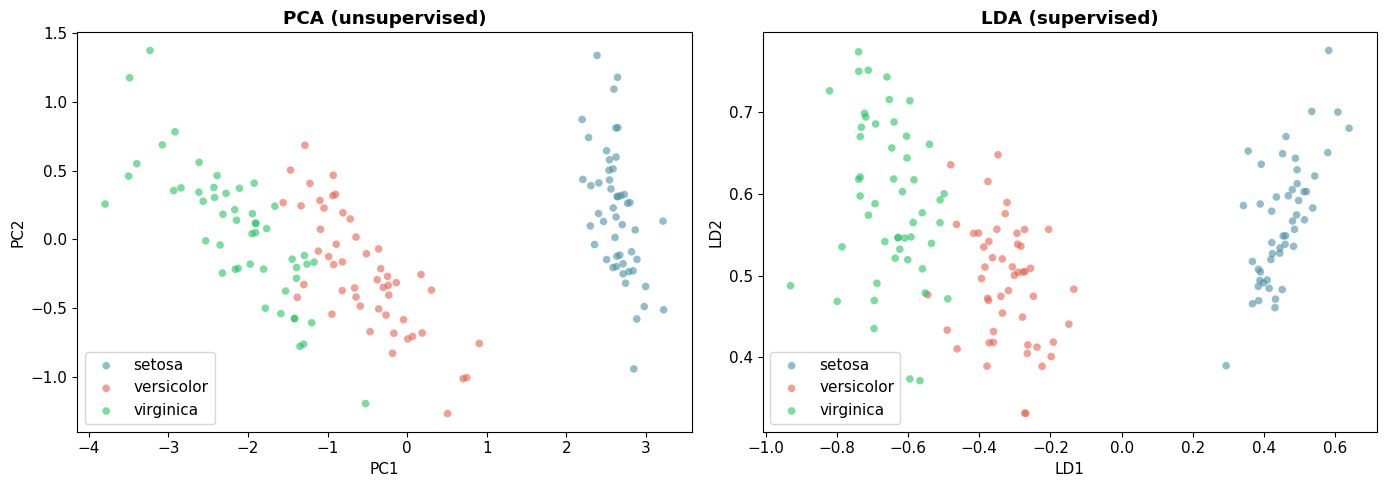

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_projection_2d(X_pca, y_iris, class_names,
                   xlabel='PC1', ylabel='PC2',
                   title='PCA (unsupervised)', ax=axes[0])
plot_projection_2d(X_lda, y_iris, class_names,
                   xlabel='LD1', ylabel='LD2',
                   title='LDA (supervised)', ax=axes[1])
plt.tight_layout()
plt.show()

### 4.3 Compare with sklearn

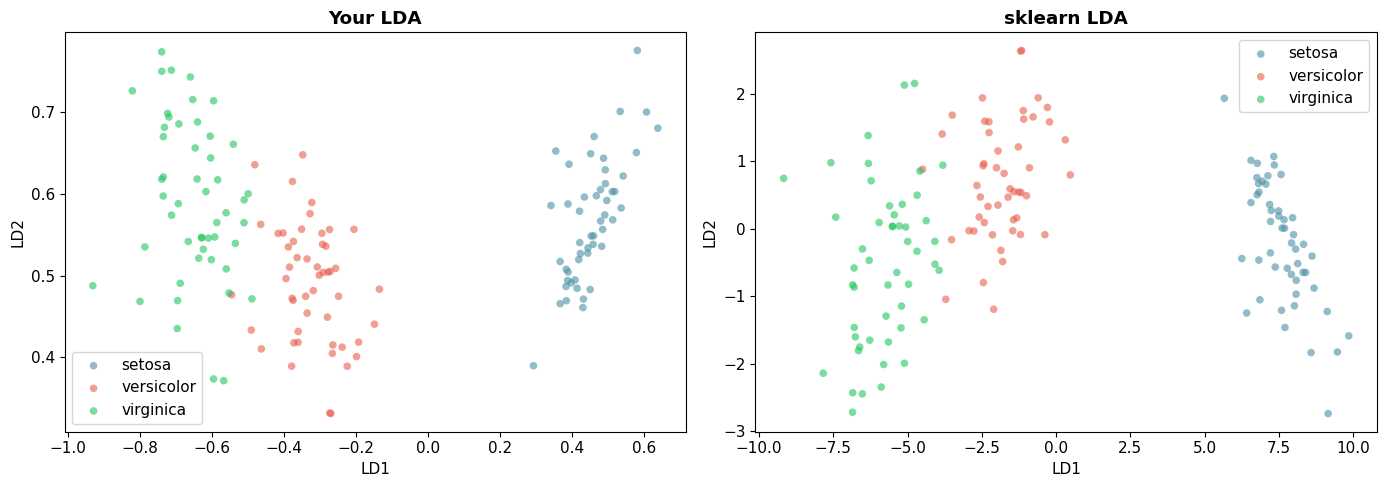

In [18]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA

lda_sk = SklearnLDA(n_components=2).fit(X_iris, y_iris)
X_lda_sk = lda_sk.transform(X_iris)

plot_comparison(X_lda, X_lda_sk, y_iris, class_names, method_name='LDA',
               xlabel='LD1', ylabel='LD2')
plt.show()

### 4.4 Conceptual Questions — LDA vs PCA

**Q4.1:** Compare the PCA and LDA projections from Section 4.2. Which method produces better class separation for the Iris dataset? Why does this make sense given how each method defines "important" directions?

*Your answer:* LDA produces better class separation for the Iris dataset. In the LDA projection, the three classes are more clearly separated with less overlap compared to PCA. This makes sense because LDA is supervised and explicitly tries to maximize separation between class means while minimizing variation within each class. In contrast, PCA is unsupervised and only finds directions that capture the most overall variance, without considering class labels. Therefore, PCA may preserve variance that is not necessarily useful for separating classes, while LDA focuses directly on discrimination.

**Q4.2:** For a classification problem with $C$ classes, what is the maximum number of LDA components you can extract? Why is this limit fundamentally different from PCA's limit of $\min(n, d)$ components?

*Your answer:* For a problem with $C$ classes, the maximum number of LDA components is $C-1$. This is because LDA focuses on separating class means, and only $C-1$ independent directions are needed to distinguish $C$ classes. This is different from PCA, which can produce up to $min(n,d)$ components because PCA is based purely on the structure of the feature space and does not depend on class labels. PCA finds directions of maximum variance in the data, while LDA is limited by the number of classes.

**Q4.3:** In what situation would PCA be a better choice than LDA for dimensionality reduction, even if you have access to class labels?

*Your answer:* When the number of samples is small compared to the number of features PCA would be a better choice than LDA, since LDA can become unstable due to estimating class covariance matrices. PCA can also be preferable when class labels are noisy or unreliable, because it does not depend on labels and instead captures the overall structure of the data. Additionally, if the goal is data compression or visualization rather than classification, PCA may be more appropriate.

---

## Part 5: Integrative Analysis — UCI Heart Disease Dataset

Now apply the tools you have built to a real-world clinical dataset. The [UCI Heart Disease dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) contains patient records with features such as age, cholesterol, resting blood pressure, and chest pain type, with a binary target indicating the presence of heart disease.

Your goal is to build a complete analysis pipeline:
1. Load and explore the data
2. Preprocess (handle missing values, encode, scale)
3. Apply PCA and LDA for dimensionality reduction and visualization
4. Use K-Means/GMM for exploratory clustering
5. Build a classification pipeline and evaluate

**Use your implementations where possible**, and sklearn for SVM/evaluation.

### 5.1 Load and Explore

In [19]:
# Load the heart disease dataset from sklearn (processed Cleveland subset)
# Alternatively, you can download from UCI directly.
# This is the standard processed version with 13 features and binary target.

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

heart_df = pd.read_csv(url, names=columns, na_values='?')

# Convert target to binary (0 = no disease, 1 = disease)
heart_df['target'] = (heart_df['target'] > 0).astype(int)

print(f"Dataset shape: {heart_df.shape}")
print(f"\nClass distribution:")
print(heart_df['target'].value_counts())
print(f"\nMissing values:")
print(heart_df.isnull().sum()[heart_df.isnull().sum() > 0])
heart_df.head()

Dataset shape: (303, 14)

Class distribution:
target
0    164
1    139
Name: count, dtype: int64

Missing values:
ca      4
thal    2
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 5.2 Data Preprocessing

**TODO:** Handle missing values, separate features and target, and standardize the features. Justify your preprocessing choices.

In [24]:
# TODO: Preprocess the data
# 1. Handle missing values (drop rows, or impute — your choice, but justify)
# 2. Separate features (X_heart) and target (y_heart)
# 3. Standardize features (you may use sklearn's StandardScaler here)
from sklearn.preprocessing import StandardScaler

heart_df_clean = heart_df.dropna().copy()

X_heart = heart_df_clean.drop(columns=["target"]).values
y_heart = heart_df_clean["target"].values

scaler = StandardScaler()
X_heart_scaled = scaler.fit_transform(X_heart)

print("After cleaning:", heart_df_clean.shape)
print("X shape:", X_heart_scaled.shape, "y shape:", y_heart.shape)

After cleaning: (297, 14)
X shape: (297, 13) y shape: (297,)


### 5.3 Dimensionality Reduction Visualization

**TODO:** Apply both your PCA and LDA to the heart disease data. Create a side-by-side comparison showing the 2D projection colored by the target class. Which method separates the classes better?

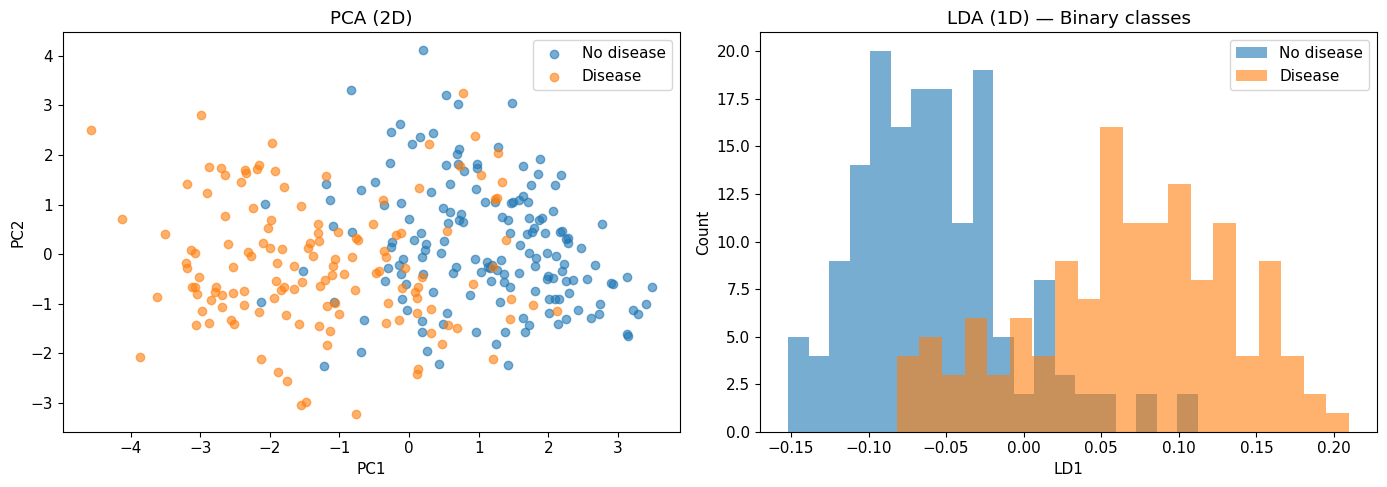

PCA explained variance ratio: [0.23695056 0.12349486]
LDA explained variance ratio: [1.]


In [25]:
# TODO: Apply your PCA (n_components=2) and your LDA (n_components=1, since binary)
# For LDA with binary classes, you only get 1 component — you can create
# a 1D projection plot (histogram by class) or combine with 1 PCA component.
import matplotlib.pyplot as plt
from dimensionality_reduction import PCA, LDAProjection  # your implementations

pca2 = PCA(n_components=2).fit(X_heart_scaled)
X_pca2 = pca2.transform(X_heart_scaled)

lda1 = LDAProjection(n_components=1).fit(X_heart_scaled, y_heart)
X_lda1 = lda1.transform(X_heart_scaled).ravel()  # make it 1D array

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca2[y_heart==0, 0], X_pca2[y_heart==0, 1], alpha=0.6, label="No disease")
axes[0].scatter(X_pca2[y_heart==1, 0], X_pca2[y_heart==1, 1], alpha=0.6, label="Disease")
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].hist(X_lda1[y_heart==0], bins=20, alpha=0.6, label="No disease")
axes[1].hist(X_lda1[y_heart==1], bins=20, alpha=0.6, label="Disease")
axes[1].set_title("LDA (1D) — Binary classes")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

print("PCA explained variance ratio:", pca2.explained_variance_ratio_)
print("LDA explained variance ratio:", lda1.explained_variance_ratio_)

### 5.4 Exploratory Clustering

**TODO:** Apply your K-Means and/or GMM to the heart disease features (in the PCA-reduced space). Do the discovered clusters align with the disease labels? Discuss.

In [26]:
# TODO: Cluster the data and compare cluster labels with disease labels
import numpy as np
from clustering import KMeans, GMM
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

X_cluster = X_pca2

km = KMeans(n_clusters=2, random_state=42).fit(X_cluster)
km_labels = km.labels_

gmm = GMM(n_components=2, random_state=42).fit(X_cluster)
gmm_labels = gmm.predict(X_cluster)

print("KMeans ARI:", adjusted_rand_score(y_heart, km_labels))
print("KMeans NMI:", normalized_mutual_info_score(y_heart, km_labels))

print("GMM ARI:", adjusted_rand_score(y_heart, gmm_labels))
print("GMM NMI:", normalized_mutual_info_score(y_heart, gmm_labels))

def contingency(y_true, y_pred):
    table = np.zeros((2, 2), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        table[int(yt), int(yp)] += 1
    return table

print("\nContingency (rows=true disease 0/1, cols=cluster 0/1)")
print("KMeans:\n", contingency(y_heart, km_labels))
print("GMM:\n", contingency(y_heart, gmm_labels))

KMeans ARI: 0.41150451698312107
KMeans NMI: 0.3359830878523741
GMM ARI: 0.23563750731827532
GMM NMI: 0.23178669112925973

Contingency (rows=true disease 0/1, cols=cluster 0/1)
KMeans:
 [[146  14]
 [ 39  98]]
GMM:
 [[ 96  64]
 [ 12 125]]


### 5.5 Classification Pipeline

**TODO:** Build a classification pipeline for heart disease prediction:
1. Split data into train/test sets (80/20, stratified)
2. Apply dimensionality reduction as a preprocessing step (your PCA or LDA)
3. Train an SVM classifier (you may use sklearn's SVC)
4. Evaluate using accuracy, and at least one other metric (precision, recall, F1, or confusion matrix)
5. Compare: does PCA or LDA preprocessing lead to better classification? What about using all features (no reduction)?

In [27]:
# TODO: Classification pipeline with evaluation
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_heart_scaled, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

def eval_svm(Xtr, Xte, ytr, yte, title):
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    acc = accuracy_score(yte, pred)
    f1 = f1_score(yte, pred)
    cm = confusion_matrix(yte, pred)
    print(f"\n--- {title} ---")
    print("Accuracy:", acc)
    print("F1:", f1)
    print("Confusion Matrix:\n", cm)
    return acc, f1


acc_none, f1_none = eval_svm(X_train, X_test, y_train, y_test, "SVM (No Reduction)")

pca = PCA(n_components=2).fit(X_train)
Xtr_pca = pca.transform(X_train)
Xte_pca = pca.transform(X_test)
acc_pca, f1_pca = eval_svm(Xtr_pca, Xte_pca, y_train, y_test, "SVM + PCA(2)")

lda = LDAProjection(n_components=1).fit(X_train, y_train)
Xtr_lda = lda.transform(X_train)
Xte_lda = lda.transform(X_test)
acc_lda, f1_lda = eval_svm(Xtr_lda, Xte_lda, y_train, y_test, "SVM + LDA(1)")

print("\nSummary:")
print("No reduction:", (acc_none, f1_none))
print("PCA(2):      ", (acc_pca, f1_pca))
print("LDA(1):      ", (acc_lda, f1_lda))


--- SVM (No Reduction) ---
Accuracy: 0.85
F1: 0.8301886792452831
Confusion Matrix:
 [[29  3]
 [ 6 22]]

--- SVM + PCA(2) ---
Accuracy: 0.8666666666666667
F1: 0.84
Confusion Matrix:
 [[31  1]
 [ 7 21]]

--- SVM + LDA(1) ---
Accuracy: 0.85
F1: 0.8301886792452831
Confusion Matrix:
 [[29  3]
 [ 6 22]]

Summary:
No reduction: (0.85, 0.8301886792452831)
PCA(2):       (0.8666666666666667, 0.84)
LDA(1):       (0.85, 0.8301886792452831)


### 5.6 Integrative Conceptual Questions

**Q5.1:** In the heart disease dataset, why is standardization particularly important before applying PCA? Consider the feature scales (e.g., cholesterol in mg/dL vs binary indicators like sex).

*Your answer:* PCA is based on max variance. If features are on different scales, the large scale features dominate the variance and PCA directions become biased. Standardization puts all features on comparable scale so PCA reflects true structure rather than units.

**Q5.2:** Did the unsupervised clustering (K-Means / GMM) discover groups that align with the disease labels? What does this tell you about whether the feature space naturally separates by disease status?

*Your answer:* The clustering results show only moderate alignment between clusters and disease labels. KMeans achieved ARI = 0.41 and NMI = 0.34, indicating partial agreement with the true labels. GMM performed worse, with ARI = 0.24 and NMI = 0.23. The contingency tables reveal that while many non-disease and disease cases are grouped together, significant mixing remains. This suggests that the dataset does not naturally form two distinct clusters corresponding to disease status. Therefore, heart disease classification likely requires supervised methods rather than relying solely on unsupervised clustering.

**Q5.3:** Comparing your classification results — which preprocessing approach (no reduction, PCA, LDA) worked best? Provide a brief explanation for why this result makes sense.

*Your answer:* SVM with PCA worked best as they achieved an accuracy and F1 score of 86.7% and 0.84. PCA likely improved performance by reducing noise and correlated dimensions while preserving most of the variance. LDA, which reduced the dataset to a single discriminant component due to binary classification, did not outperform the baseline. This suggests that while supervised dimensionality reduction can enhance class separation, excessive compression may remove useful information. Overall, moderate dimensionality reduction via PCA provided the best trade-off between noise reduction and information preservation.

---

## Submission Checklist

Before submitting, verify:

- [ ] All cells in this notebook run without errors (Kernel → Restart & Run All)
- [ ] All TODO code cells are completed
- [ ] All conceptual questions are answered (Q1.1–Q1.3, Q2.1–Q2.4, Q3.1–Q3.3, Q4.1–Q4.3, Q5.1–Q5.3)
- [ ] `clustering.py` is complete (KMeans and GMM)
- [ ] `dimensionality_reduction.py` is complete (PCA and LDAProjection)
- [ ] PDF export of this notebook is included

**Submit:** `clustering.py`, `dimensionality_reduction.py`, `HW3_Analysis.ipynb`, `HW3_Analysis.pdf`